In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Load dataset (using your Indonesian names or standard names)
words = open('../data/names.txt', 'r').read().splitlines()
words = [w.strip().lower() for w in words if w.strip().isalpha()]

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos) # 27

In [21]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        # Kaiming He normal init: gain / sqrt(fan_in)
        # We use gain = 5/3 for tanh activation that usually follows
        self.weight = torch.randn((fan_in, fan_out)) * (5/3) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        
        # Learnable scale (gamma) and shift (beta)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
        # Running buffers (not trained by gradient descent!)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate forward pass
        if self.training:
            # Batch mean and batch variance across the batch dimension (dim 0)
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            # At test/inference time, use the accumulated running statistics!
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize to zero mean, unit variance
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        # Scale and shift
        self.out = self.gamma * xhat + self.beta

        # Update running buffers with exponential moving average during training
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

In [22]:
# Context size (let's use your 3 or 5 chars!)
BLOCK_SIZE = 3
EMBEDDING_DIM = 10
HIDDEN_DIM = 100

# Prepare dataset tensors
X, Y = [], []
for w in words:
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

# Split train (80%), val (10%), test (10%)
n1 = int(0.8 * len(X))
n2 = int(0.9 * len(X))
Xtr, Ytr = X[:n1], Y[:n1]
Xdev, Ydev = X[n1:n2], Y[n1:n2]
Xte, Yte = X[n2:], Y[n2:]

torch.manual_seed(42)

# Build a 5-layer deep MLP!
# Notice: Every Linear followed by BatchNorm has bias=False!
layers = [
    Embedding(vocab_size, EMBEDDING_DIM),
    Flatten(),
    Linear(BLOCK_SIZE * EMBEDDING_DIM, HIDDEN_DIM, bias=False),
    BatchNorm1d(HIDDEN_DIM),
    Tanh(),
    Linear(HIDDEN_DIM, HIDDEN_DIM, bias=False),
    BatchNorm1d(HIDDEN_DIM),
    Tanh(),
    Linear(HIDDEN_DIM, HIDDEN_DIM, bias=False),
    BatchNorm1d(HIDDEN_DIM),
    Tanh(),
    Linear(HIDDEN_DIM, vocab_size, bias=False),
    BatchNorm1d(vocab_size), # Optional, or just raw linear
]

# FIX DISASTER #1: Tame the output layer so initial loss is ~ -log(1/vocab_size)
with torch.no_grad():
    # Make the last layer less confident at initialization
    layers[-1].gamma *= 0.1

# Collect all parameters and enable gradients
parameters = [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

print(f"Total trainable parameters: {sum(p.nelement() for p in parameters)}")

Total trainable parameters: 26624


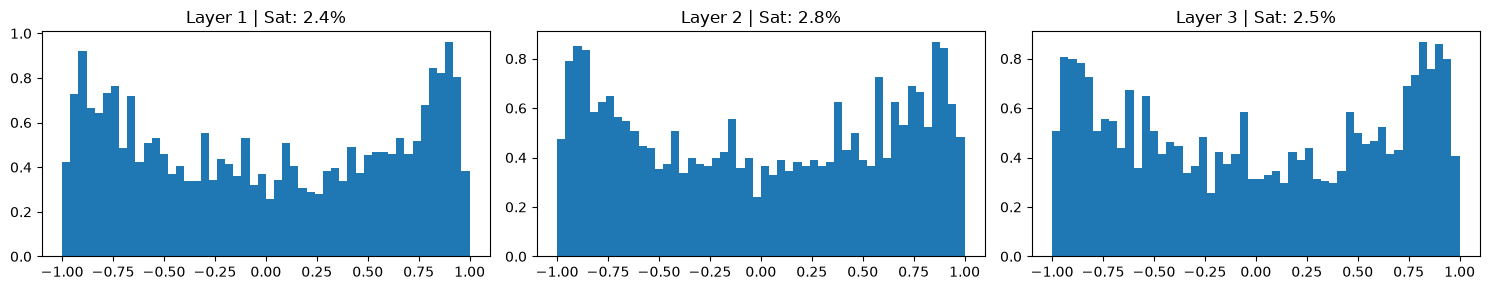

In [23]:
# Forward pass of 1 batch to inspect
ix = torch.randint(0, Xtr.shape[0], (32,))
x = Xtr[ix]
for layer in layers:
    x = layer(x)

# Check saturation in the Tanh layers
tanh_layers = [layer for layer in layers if isinstance(layer, Tanh)]
plt.figure(figsize=(15, 3))
for i, layer in enumerate(tanh_layers):
    plt.subplot(1, len(tanh_layers), i+1)
    # How many values are near extremes |out| > 0.97?
    saturated = (layer.out.abs() > 0.97).float().mean().item()
    plt.hist(layer.out.view(-1).data.numpy(), bins=50, range=(-1, 1), density=True)
    plt.title(f"Layer {i+1} | Sat: {saturated*100:.1f}%")
plt.tight_layout()
plt.show()

In [24]:
max_steps = 20000
batch_size = 64
lossi = []

for i in range(max_steps):
    # 1. Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # 2. Forward pass
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # 3. Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # 4. Optimizer update (learning rate decay)
    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # Track progress
    if i % 2000 == 0 or i == max_steps - 1:
        print(f"Step {i:6d} / {max_steps} | Loss: {loss.item():.4f}")
    lossi.append(loss.item())

Step      0 / 20000 | Loss: 3.2983
Step   2000 / 20000 | Loss: 2.4971
Step   4000 / 20000 | Loss: 2.2114
Step   6000 / 20000 | Loss: 2.2458
Step   8000 / 20000 | Loss: 2.5306
Step  10000 / 20000 | Loss: 2.0421
Step  12000 / 20000 | Loss: 2.1405
Step  14000 / 20000 | Loss: 1.9792
Step  16000 / 20000 | Loss: 1.9895
Step  18000 / 20000 | Loss: 2.1103
Step  19999 / 20000 | Loss: 2.3034


In [26]:
# Put model in EVAL mode!
for layer in layers:
    if hasattr(layer, 'training'):
        layer.training = False

# Evaluate on validation set
with torch.no_grad():
    x = Xdev
    for layer in layers:
        x = layer(x)
    val_loss = F.cross_entropy(x, Ydev)
    print(f"Validation Loss: {val_loss.item():.4f}")

# Sample 15 new names
g = torch.Generator().manual_seed(42)
print("\n--- Generated Names ---")
for _ in range(15):
    out = []
    context = [0] * BLOCK_SIZE
    
    while True:
        # Forward pass with context of shape (1, BLOCK_SIZE)
        x = torch.tensor([context])
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        
        # Sample from distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        if ix == 0:
            break
            
        out.append(itos[ix])
        context = context[1:] + [ix]
        
    print(''.join(out))

Validation Loss: 2.3536

--- Generated Names ---
anuedenvi
s
marian
dante
naysia
aley
kemarce
man
emiah
aden
dazi
kenda
jordon
kalla
mikolynn
